# Case 2 - TD 1 


✓ Plot saved as 'case2_pulsed_input.png'


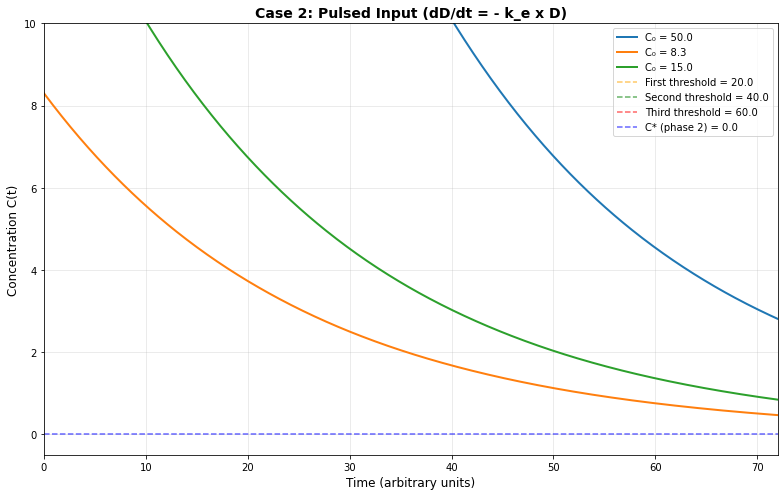


CASE 2: PULSED INPUT MODEL
Elimination coefficient (k): 0.04


PHASE 2 (t ≥ 0.0):
  Equilibrium C*₂:           0.00

Number of simulations:       3

✓ Simulation completed successfully.

Key observations:
  - Trajectories decay toward D* = 0.0
  - The transition is continuous (no jump), but the derivative is discontinuous
  - The first threshold is = 20.0
  - The second threshold is = 40.0
  - The third threshold is = 60.0


In [2]:
"""
Case 2: Pulsed Input Model
===========================

Description:
    Simulates a substance with time-dependent input. The input is constant for
    a finite duration (pulse), then drops to zero.

    Mathematical model:
        dC/dt = e(t) - k*C

    where:
        e(t) = pulse function (constant during pulse, zero after)
        k    = elimination coefficient

    Physical interpretation:
        - Phase 1 (0 ≤ t < t_pulse): Input active, system rises toward equilibrium
        - Phase 2 (t ≥ t_pulse): Input stops, system decays to zero

Author: TD1 - Module 1
Date: 2026
License: MIT (for educational purposes)
"""

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


# ==============================================================================
# PARAMETERS
# ==============================================================================
# Input parameters

# E_PULSE = 4.0           # Input magnitude during pulse [units: concentration/time]
T_PULSE_END = 0.0      # Time when pulse ends [units: time]

# Elimination
k_e = 0.04     # Elimination coefficient [units: 1/time]

# Analytical equilibria (by phase)
# C_EQUILIBRIUM_PHASE1 = E_PULSE / K_ELIMINATION  # During pulse: C* = e/k
D_EQUILIBRIUM_PHASE2 = 0.0                      # After pulse: C* = 0/k = 0

# Numerical parameters
T_FINAL = 72.0          # Final simulation time
N_POINTS = 500          # Higher resolution for better accuracy
INITIAL_CONDITIONS = [50.0, 8.3, 15.0]  # Three different starting concentrations (in mg/kg)

THRESHOLD_1 = 20.0      # (in mg/kg)
THRESHOLD_2 = 40.0      # (in mg/kg)
THRESHOLD_3 = 60.0      # (in mg/kg)

# ==============================================================================
# PULSED INPUT FUNCTION
# ==============================================================================
"""
def e_pulse(t):
    
    Time-dependent input function.

    Parameters
    ----------
    t : float
        Current time

    Returns
    -------
    float
        Input rate at time t
    
    if t < T_PULSE_END:
        return E_PULSE  # Pulse is active
    else:
        return 0.0      # Pulse has ended
"""

# ==============================================================================
# RIGHT-HAND SIDE (RHS) OF THE ODE
# ==============================================================================
def rhs(t, D, k_e):
    """
    Compute the right-hand side of the ODE: dC/dt = e(t) - k*C

    Parameters
    ----------
    t : float
        Current time
    C : array-like
        Current state, where C[0] is the concentration
    k : float
        Elimination coefficient

    Returns
    -------
    float
        The derivative dC/dt at time t
    """
    # e_t = e_pulse(t)  # Evaluate input function at time t
    return - k_e * D[0]


# ==============================================================================
# SOLVE AND PLOT
# ==============================================================================
def main():
    """
    Main function: solve the ODE for multiple initial conditions.
    """

    # Time evaluation points
    t_eval = np.linspace(0, T_FINAL, N_POINTS)

    # Create figure
    fig, ax = plt.subplots(figsize=(11, 7))

    # Solve for each initial condition
    for c0 in INITIAL_CONDITIONS:
        solution = solve_ivp(
            fun=lambda t, C: rhs(t, C, k_e),
            t_span=(0, T_FINAL),
            y0=[c0],
            t_eval=t_eval,
            method='RK45',
            dense_output=False
        )

        # Plot the solution
        ax.plot(solution.t, solution.y[0], label=f"C₀ = {c0}", linewidth=2)

    # Add phase separation line
    # ax.axvline(
        # T_PULSE_END,
        # color='gray',
        # linestyle=':',
        # linewidth=2,
        # label='Pulse ends'
    # )

    # Add equilibrium lines for each phase
    
    ax.axhline(
        THRESHOLD_1,
        linestyle='--',
        color='orange',
        linewidth=1.5,
        alpha=0.6,
        label=f"First threshold = {THRESHOLD_1:.1f}"
    )
    
    ax.axhline(
        THRESHOLD_2,
        linestyle='--',
        color='green',
        linewidth=1.5,
        alpha=0.6,
        label=f"Second threshold = {THRESHOLD_2:.1f}"
    )

    ax.axhline(
        THRESHOLD_3,
        linestyle='--',
        color='red',
        linewidth=1.5,
        alpha=0.6,
        label=f"Third threshold = {THRESHOLD_3:.1f}"
    )

    ax.axhline(
        D_EQUILIBRIUM_PHASE2,
        linestyle='--',
        color='blue',
        linewidth=1.5,
        alpha=0.6,
        label=f"C* (phase 2) = {D_EQUILIBRIUM_PHASE2:.1f}"
    )

    # Formatting
    ax.set_xlabel("Time (arbitrary units)", fontsize=12)
    ax.set_ylabel("Concentration C(t)", fontsize=12)
    ax.set_title("Case 2: Pulsed Input (dD/dt = - k_e x D)", fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, T_FINAL)
    ax.set_ylim(-0.5, 10)

    plt.tight_layout()
    plt.savefig('case2_pulsed_input.png', dpi=150, bbox_inches='tight')
    print("✓ Plot saved as 'case2_pulsed_input.png'")

    plt.show()

    # Print analytical results
    print("\n" + "="*70)
    print("CASE 2: PULSED INPUT MODEL")
    print("="*70)
    # print(f"Pulse amplitude (e):         {E_PULSE:.2f}")
    # print(f"Pulse duration:              0.0 to {T_PULSE_END:.2f}")
    print(f"Elimination coefficient (k): {k_e:.2f}")
    print(f"")
    # print(f"PHASE 1 (0 ≤ t < {T_PULSE_END}):")
    # print(f"  Equilibrium C*₁:           {C_EQUILIBRIUM_PHASE1:.2f}")
    print(f"")
    print(f"PHASE 2 (t ≥ {T_PULSE_END}):")
    print(f"  Equilibrium C*₂:           {D_EQUILIBRIUM_PHASE2:.2f}")
    print(f"")
    print(f"Number of simulations:       {len(INITIAL_CONDITIONS)}")
    print("="*70)


# ==============================================================================
# REPRODUCIBILITY AND EXECUTION
# ==============================================================================
if __name__ == "__main__":
    np.random.seed(42)
    main()

    print("\n✓ Simulation completed successfully.")
    print("\nKey observations:")
    # print(f"  - During phase 1 (0 ≤ t < {T_PULSE_END}): trajectories rise toward C* = {C_EQUILIBRIUM_PHASE1:.1f}")
    # print(f"  - At t = {T_PULSE_END}: input stops, derivative changes sign")
    print(f"  - Trajectories decay toward D* = {D_EQUILIBRIUM_PHASE2:.1f}")
    print(f"  - The transition is continuous (no jump), but the derivative is discontinuous")
    print(f"  - The first threshold is = {THRESHOLD_1:.1f}")
    print(f"  - The second threshold is = {THRESHOLD_2:.1f}")
    print(f"  - The third threshold is = {THRESHOLD_3:.1f}")


## TD 2 Block 2

Analytical equilibrium for D=9.6: S* = 0.0003


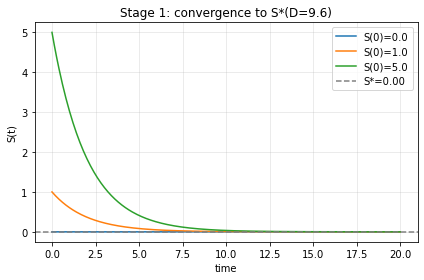

ValueError: x and y must have same first dimension, but have shapes (400,) and (1,)

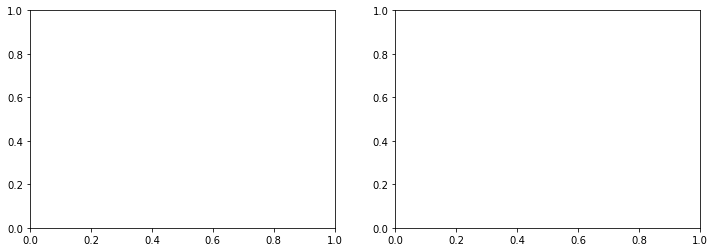

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
# Parameters
rho, K_D, n, mu_S = 0.075, 80, 3, 0.5
D = 9.6
def rhs(t, S, D):
    production = rho*(D**n/(K_D**n + D**n))*(1 - S)
    return production - mu_S * S

# Compute equilibrium analytically
S_star = (rho*D**n) / (mu_S*(K_D**n - D**n) + rho*D**n)
print(f"Analytical equilibrium for D={D}: S* = {S_star:.4f}")
# Simulate from three initial conditions
t_eval = np.linspace(0, 20, 300)
for S0 in [0.0, 1.0, 5.0]:
    sol = solve_ivp(lambda t, S: rhs(t, S, D),
        (0, 20), [S0], t_eval=t_eval,
        method="RK45", rtol=1e-8, atol=1e-10)
    plt.plot(sol.t, sol.y[0], label=f"S(0)={S0}")
plt.axhline(S_star, ls="--", color="gray", label=f"S*={S_star:.2f}")
plt.xlabel("time")
plt.ylabel("S(t)")
plt.title(f"Stage 1: convergence to S*(D={D})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

p_values = np.logspace(-2, 2, 400)
S_star_values = (rho*D**n) / (mu_S*(K_D**n - D**n) + rho*D**n)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# Linear axes
ax1.plot(p_values, S_star_values, linewidth=2)
ax1.set_xlabel("D")
ax1.set_ylabel("S*(D)")
ax1.set_title("Dose-response (linear axes)")
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 10])


# Semilogarithmic p-axis
ax2.semilogx(p_values, S_star_values, linewidth=2)
ax2.set_xlabel("D (log scale)")
ax2.set_ylabel("S*(D)")
ax2.set_title("Dose-response (semilog p-axis)")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
#plt.axhline(4, linestyle="--", label="S_max")
#plt.axvline(1, linestyle=":", label="EC50 = K")
plt.legend()
plt.show()